# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**: Not necessary
* **The purpose of this Notebook**:
* **Dataset**: [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel)
  * patients evaluated in a real clinical environment, representing a heterogeneous population with mixed sleep pathologies (insomnia, apnea, movement disorders), reflecting the typical and unfiltered casuistry of a hospital sleep center.
* **Input**: None.
* **Output:**
    * Folders train, val and test.

# Importing

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 26.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import os
import requests
import shutil
import os
import mne
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display
import glob
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from huggingface_hub import HfApi
from huggingface_hub.utils import disable_progress_bars

warnings.filterwarnings("ignore")
mne.set_log_level('ERROR')

In [5]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data/raw_dataset'
original_dir = '/content/hmc'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Download

In [ ]:
def download_hmc_subject(subject_id, output_dir):
    '''Download HMC Dataset'''
    base_url = "https://physionet.org/files/hmc-sleep-staging/1.1/recordings/"

    files_to_fetch = [f"{subject_id}.edf", f"{subject_id}_sleepscoring.edf"]

    for filename in files_to_fetch:
        url = base_url + filename
        local_path = os.path.join(output_dir, filename)

        if os.path.exists(local_path):
            # print(f"File {filename} already exists. Skipping...")
            continue

        print(f"Downloading {filename}...")
        try:
            r = requests.get(url, stream=True)
            if r.status_code == 200:
                with open(local_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=1024):
                        f.write(chunk)
            else:
                print(f"File not found on server (Status: {r.status_code}) - URL: {url}")
        except Exception as e:
            print(f"Error: {e}")

In [ ]:
hmc_output_dir = os.path.join(base_path, "hmc")

if not os.path.exists(hmc_output_dir):
    os.makedirs(hmc_output_dir)

hmc_subjects = [f"SN{i:03d}" for i in range(154, 78,-1)]
excluded_subjects = ["SN014", "SN064", "SN135"]
for subj in hmc_subjects:
    if subj not in excluded_subjects:
        download_hmc_subject(subj, hmc_output_dir)

print(f"Done! Files downloaded at: {hmc_output_dir}")

Done! Files downloaded at: /content/drive/MyDrive/sleep_data/raw_dataset/hmc


# Vizualization

In [ ]:
def vizualization_hmc(base_path, subject_id):
    edf_path = os.path.join(base_path, f"{subject_id}.edf")
    scoring_path = os.path.join(base_path, f"{subject_id}_sleepscoring.edf")

    print(f"Signal loading: {edf_path}")
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

    print(f"Loading annotations: {scoring_path}")
    annotations = mne.read_annotations(scoring_path)
    raw.set_annotations(annotations)

    print("Annotations found in the file:", set(raw.annotations.description))
    print(f"Total recording time: {raw.times[-1]:.2f} seconds")

    target_ch = [ch for ch in raw.ch_names if "C4" in ch.upper()]
    target_ch = target_ch[0] if target_ch else raw.ch_names[0]

    duration = 30
    max_start = max(0, raw.times[-1] - duration)
    start_sec = min(1000, max_start)

    try:
        raw.plot(start=start_sec, duration=duration, order=[raw.ch_names.index(target_ch)],
                 scalings={'eeg': 100e-6}, n_channels=1, show_options=True)
    except Exception as e:
        print(f"Could not display raw signal: {e}")

    desc = set(raw.annotations.description)
    mapping = {}
    for d in desc:
        d_upper = d.upper()
        if 'W' in d_upper: mapping[d] = 0
        elif '1' in d_upper: mapping[d] = 1
        elif '2' in d_upper: mapping[d] = 2
        elif '3' in d_upper or '4' in d_upper: mapping[d] = 3
        elif 'R' in d_upper: mapping[d] = 4

    events, _ = mne.events_from_annotations(raw, event_id=mapping, chunk_duration=30.0)

    if len(events) == 0:
        print("Error.")
        return

    hypnogram = events[:, 2]
    time_hours = np.arange(len(hypnogram)) * 30 / 3600

    plt.figure(figsize=(15, 5))
    plt.step(time_hours, hypnogram, where='post', color='#e74c3c')
    plt.yticks([0, 1, 2, 3, 4], ['Wake', 'N1', 'N2', 'N3', 'REM'])
    plt.gca().invert_yaxis()
    plt.title(f"Hypnogram - {subject_id}")
    plt.xlabel("Time (Hours)")
    plt.grid(True)
    plt.show()

Signal loading: /content/drive/MyDrive/sleep_data/raw_dataset/hmc/SN001.edf
Loading annotations: /content/drive/MyDrive/sleep_data/raw_dataset/hmc/SN001_sleepscoring.edf
Annotations found in the file: {np.str_('Lights on@@EEG Fpz-Cz'), np.str_('Sleep stage W'), np.str_('Sleep stage N1'), np.str_('Lights off@@EEG F4-A1'), np.str_('Sleep stage N3'), np.str_('Sleep stage R'), np.str_('Sleep stage N2')}
Total recording time: 25650.00 seconds


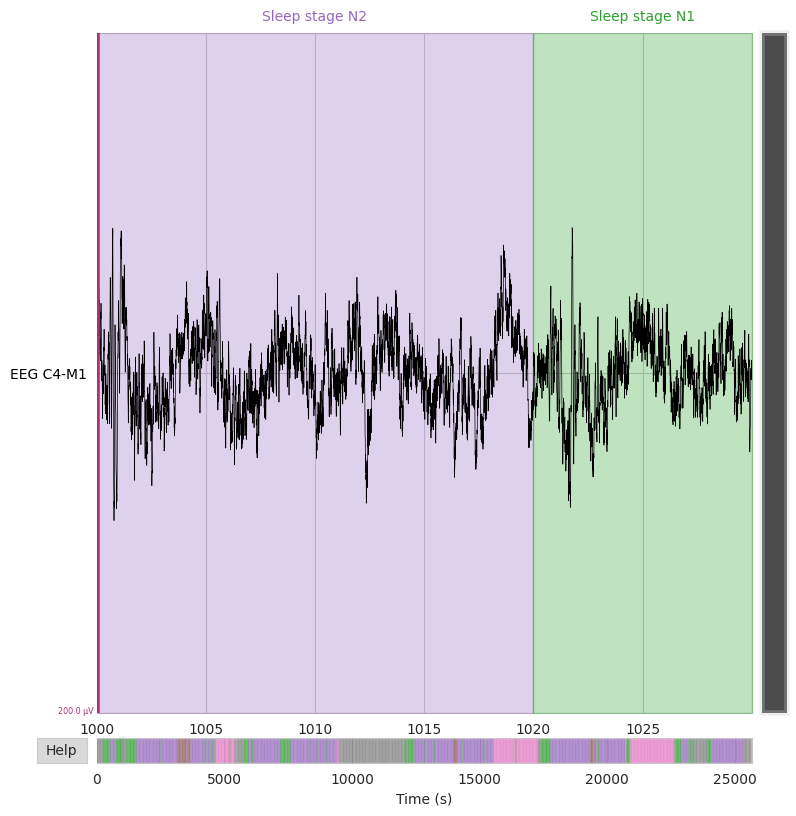

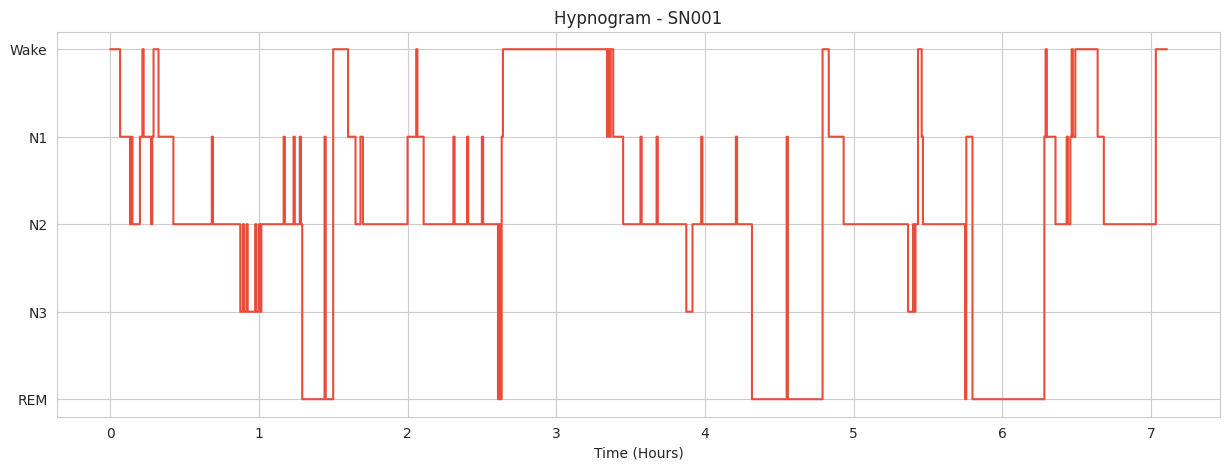

In [ ]:
vizualization_hmc(base_path + '/hmc', 'SN001')

# ETL

## Quality check

In [ ]:
class HMCLabelMapping:
    '''
    Handles the process for HMC Sleep Staging Database (v1.1) signals.
    Adapts the logic to handle AASM string annotations from EDF and C4-M1 channels.
    '''
    def __init__(self, output_dir, sfreq=100, epoch_sec=30):
        self.output_dir = output_dir
        self.sfreq = sfreq
        self.epoch_sec = epoch_sec

        # Make sure the folder exists
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)

    def __load_and_clean_psg(self, psg_path):
        '''
        Loads the EDF, finds the best EEG channel (C4-M1),
        resamples to 100Hz and applies Bandpass filter (0.3Hz - 35Hz).
        '''
        # 1. Load (MNE) - Suppress warnings
        mne.set_log_level('ERROR')
        raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)

        # 2. Dynamic Channel Selection (HMC Specific: looking for M1 references)
        target_ch = None
        for ch in raw.ch_names:
            if "C4" in ch and "M1" in ch:
                target_ch = ch
                break

        # Fallback to F4-M1 or the first channel if C4 is missing
        if target_ch is None:
            candidates = [ch for ch in raw.ch_names if "F4" in ch and "M1" in ch]
            if candidates:
                target_ch = candidates[0]
            else:
                target_ch = raw.ch_names[0] # Ultimate fallback
                print(f"Warning: Standard C4/F4 not found. Using {target_ch}")

        # 3. Pick channel
        raw.pick_channels([target_ch])

        # 4. Resampling
        if raw.info['sfreq'] != self.sfreq:
            raw.resample(self.sfreq)

        # 5. Bandpass Filtering (0.3Hz - 35Hz)
        raw.filter(l_freq=0.3, h_freq=35.0, verbose=False)

        return raw

    def __extract_events_from_edf(self, hypno_path, raw):
        '''
        Reads HMC string annotations from the sleepscoring.edf file
        and maps them to standard 0-4 integers using MNE.
        '''
        # 1. Map HMC string labels to Standard (AASM)
        hmc_mapping = {
            'Sleep stage W': 0,
            'Sleep stage N1': 1,
            'Sleep stage N2': 2,
            'Sleep stage N3': 3,
            'Sleep stage R': 4
        }

        # 2. Load annotations metadata
        try:
            annotations = mne.read_annotations(hypno_path)
        except Exception as e:
            raise RuntimeError(f"Cannot read annotations from {hypno_path}: {e}")

        # 3. Set annotations to the raw EEG signal
        raw.set_annotations(annotations)

        # 4. Extract events (MNE handles the 30s epoch chunking automatically)
        events, event_id = mne.events_from_annotations(
            raw,
            event_id=hmc_mapping,
            chunk_duration=self.epoch_sec,
            verbose=False
        )

        return events, event_id

    def __create_epochs(self, raw, events, event_id):
        '''Segments the signal using the extracted events.'''
        tmax = self.epoch_sec - 1. / raw.info['sfreq']

        # Ensure we don't request epochs that exceed the signal length
        max_sample = len(raw.times)
        valid_events = events[events[:, 0] + (self.epoch_sec * self.sfreq) <= max_sample]

        epochs = mne.Epochs(
            raw,
            valid_events,
            event_id=event_id,
            tmin=0., tmax=tmax,
            baseline=None,
            preload=True,
            verbose=False,
            on_missing='ignore'
        )
        return epochs

    def __save_data(self, subject_id, epochs):
        '''Converts to uV and saves to .npz'''
        # X: (n_epochs, n_channels, n_samples)
        X = epochs.get_data() * 1e6

        # Transpose for DeepSleepNet expected shape (Batch, Time, Channel)
        X = np.moveaxis(X, 1, 2)

        # y: labels (3rd column of events array)
        y = epochs.events[:, 2]

        save_path = os.path.join(self.output_dir, f"{subject_id}.npz")
        np.savez_compressed(save_path, x=X, y=y, fs=self.sfreq)

        return X.shape, y.shape

    def __process_single_subject(self, row):
        '''Pipeline wrapper.'''
        subject_id = os.path.splitext(os.path.basename(row['psg_path']))[0]

        if os.path.exists(os.path.join(self.output_dir, f"{subject_id}.npz")):
            return "" # "Skipped (Exists)"

        try:
            # 1. Signal Processing
            raw = self.__load_and_clean_psg(row['psg_path'])

            # 2. Extract Events (HMC Specific)
            events, event_map = self.__extract_events_from_edf(row['hypno_path'], raw)

            # 3. Windowing
            epochs = self.__create_epochs(raw, events, event_map)

            # 4. Save
            if len(epochs) > 0:
                x_shape, y_shape = self.__save_data(subject_id, epochs)
                return f"Success {x_shape}"
            else:
                return "Error: No epochs generated (mismatch lengths?)"

        except Exception as e:
            return f"Error: {str(e)}"

    def run(self, df):
        '''Iterates through validated files.'''
        print("Start HMC Labeling & ETL Process")
        print(f"Output: {self.output_dir}")

        results = []
        total_files = len(df)

        for i, (index, row) in enumerate(df.iterrows()):
            subj_id = os.path.basename(row['psg_path'])

            status = self.__process_single_subject(row)
            results.append({'id': subj_id, 'etl_status': status})

            if "Error" in status:
                print(f"Error {subj_id}: {status}")
            else:
                if (i + 1) % 5 == 0:
                    print(f"Progress: {i + 1}/{total_files} processed...")

        print("\nPipeline Finished.")
        return pd.DataFrame(results)

In [ ]:
base_path_hmc = base_path + '/hmc'

psg_files = [
    f for f in glob.glob(os.path.join(base_path_hmc, "*.edf"))
    if not f.endswith("_sleepscoring.edf")
]
valid_pairs = []

for psg_path in psg_files:
    base_name = os.path.basename(psg_path).replace('.edf', '')
    expected_hypno_path = os.path.join(base_path_hmc, f"{base_name}_sleepscoring.edf")
    if os.path.exists(expected_hypno_path):
        valid_pairs.append({
            'psg_path': psg_path,
            'hypno_path': expected_hypno_path
        })
    else:
        print(f"Missing annotation for: {base_name}")

# 3. Acum creăm DataFrame-ul DOAR din perechile complete
df_hmc = pd.DataFrame(valid_pairs)

# Dacă am găsit fișiere, rulăm procesul ETL
if not df_hmc.empty:
    hmc_labeler = HMCLabelMapping('/content/hmc_processed')
    etl_results_hmc = hmc_labeler.run(df_hmc)

    print("\n--- Summary of Failures ---")
    # Fix: Use a single regex pattern 'Success|' to match 'Success' or an empty string
    print(etl_results_hmc[~etl_results_hmc['etl_status'].str.contains('Success|')])

    del hmc_labeler
else:
    print("Could not process data because DataFrame is empty.")

Start HMC Labeling & ETL Process
Output Directory: /content/hmc_processed

Pipeline Finished.

--- Summary of Failures ---
Empty DataFrame
Columns: [id, etl_status]
Index: []


## Label Mapping & Epoch Segmentation

In [ ]:
class HMCLabelMapping:
    '''
    Manages the ETL process for signals from the HMC Sleep Staging Database and dynamically searches for EEG channels, mainly C4-M1.
    '''
    def __init__(self, output_dir, sfreq=100, epoch_sec=30):
        self.output_dir = output_dir
        self.sfreq = sfreq
        self.epoch_sec = epoch_sec

        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)

    def __load_and_clean_psg(self, psg_path):
        mne.set_log_level('ERROR')
        raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)

        target_ch = None
        for ch in raw.ch_names:
            if "C4" in ch.upper() and ("M1" in ch.upper() or "A1" in ch.upper()):
                target_ch = ch
                break

        if target_ch is None:
            candidates = [ch for ch in raw.ch_names if "C4" in ch.upper() or "F4" in ch.upper()]
            if candidates:
                target_ch = candidates[0]
            else:
                target_ch = raw.ch_names[0]
                print(f"Warning: {target_ch}")

        raw.pick_channels([target_ch])

        # Resampling
        if raw.info['sfreq'] != self.sfreq:
            raw.resample(self.sfreq)

        # Filtrare Bandpass (0.3Hz - 35Hz)
        raw.filter(l_freq=0.3, h_freq=35.0, verbose=False)

        return raw

    def __extract_events_from_edf(self, hypno_path, raw):
        hmc_mapping = {
            'Sleep stage W': 0,
            'Sleep stage N1': 1,
            'Sleep stage N2': 2,
            'Sleep stage N3': 3,
            'Sleep stage R': 4
        }

        try:
            annotations = mne.read_annotations(hypno_path)
        except Exception as e:
            raise RuntimeError(f"Error {hypno_path}: {e}")

        raw.set_annotations(annotations)

        events, event_id = mne.events_from_annotations(
            raw,
            event_id=hmc_mapping,
            chunk_duration=self.epoch_sec,
            verbose=False
        )

        return events, event_id

    def __create_epochs(self, raw, events, event_id):
        tmax = self.epoch_sec - 1. / raw.info['sfreq']

        max_sample = len(raw.times)
        valid_events = events[events[:, 0] + (self.epoch_sec * self.sfreq) <= max_sample]

        epochs = mne.Epochs(
            raw,
            valid_events,
            event_id=event_id,
            tmin=0., tmax=tmax,
            baseline=None,
            preload=True,
            verbose=False,
            on_missing='ignore'
        )
        return epochs

    def __save_data(self, subject_id, epochs):
        X = epochs.get_data() * 1e6
        X = np.moveaxis(X, 1, 2)
        y = epochs.events[:, 2]

        save_path = os.path.join(self.output_dir, f"{subject_id}.npz")
        np.savez_compressed(save_path, x=X, y=y, fs=self.sfreq)

        return X.shape, y.shape

    def __process_single_subject(self, row):
        subject_id = os.path.basename(row['psg_path']).replace('.edf', '')

        if os.path.exists(os.path.join(self.output_dir, f"{subject_id}.npz")):
            return "" # "Skipped (Exists)"

        try:
            raw = self.__load_and_clean_psg(row['psg_path'])
            events, event_map = self.__extract_events_from_edf(row['hypno_path'], raw)
            epochs = self.__create_epochs(raw, events, event_map)
            if len(epochs) > 0:
                x_shape, y_shape = self.__save_data(subject_id, epochs)
                return f"Success {x_shape}"
            else:
                return "Error: No epochs generated"

        except Exception as e:
            return f"Error: {str(e)}"

    def run(self, df):
        print("Start HMC Labeling & ETL Process")
        print(f"Output Directory: {self.output_dir}")

        results = []
        total_files = len(df)

        for i, (index, row) in enumerate(df.iterrows()):
            subj_id = os.path.basename(row['psg_path'])

            status = self.__process_single_subject(row)
            results.append({'id': subj_id, 'etl_status': status})

            if "Error" in status:
                print(f"Error {subj_id}: {status}")
            else:
                if (i + 1) % 5 == 0:
                    print(f"Progress: {i + 1}/{total_files} processed...")

        print("\nPipeline Finished.")
        return pd.DataFrame(results)

if not df_hmc.empty:
    output_folder = '/content/hmc_processed'
    hmc_labeler = HMCLabelMapping(output_dir=output_folder)
    etl_results = hmc_labeler.run(df_hmc)

    print("\n--- Summary of Failures ---")
    erori = etl_results_hmc[~etl_results_hmc['etl_status'].str.contains('Success|')]
    if erori.empty:
        print("All file process with success.")
    else:
        print(erori.to_string())

    del hmc_labeler
else:
    print("Error, empty dataframe.")

Start HMC Labeling & ETL Process
Output Directory: /content/hmc_processed
Progress: 5/76 processed...
Progress: 10/76 processed...
Progress: 15/76 processed...
Progress: 20/76 processed...
Progress: 25/76 processed...
Progress: 30/76 processed...
Progress: 35/76 processed...
Progress: 40/76 processed...
Progress: 45/76 processed...
Progress: 50/76 processed...
Progress: 55/76 processed...
Progress: 60/76 processed...
Progress: 65/76 processed...
Progress: 70/76 processed...
Progress: 75/76 processed...

Pipeline Finished.

--- Summary of Failures ---
All file process with success.


## Data distribution analysis


=== DATA DISTRIBUTION (HMC Dataset) ===
Total Epochs: 118307


,Class,Count,Percentage
0,Wake (W),20921,17.683654
1,N1,13596,11.492135
2,N2,42463,35.892213
3,Deep (N3),23657,19.996281
4,REM,17670,14.935718


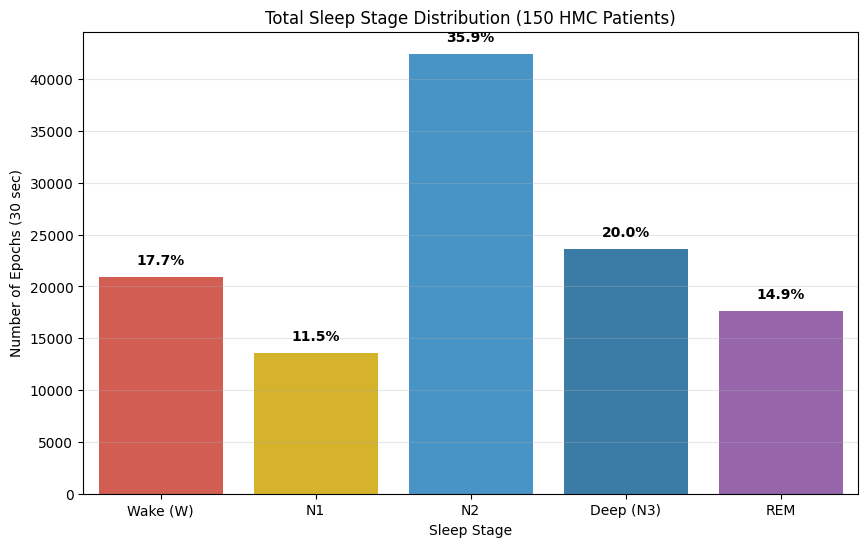

In [9]:
hmc_processed_dir = '/content/hmc_processed'

files = glob.glob(os.path.join(hmc_processed_dir, "*.npz"))

class_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
class_names = {0: 'Wake (W)', 1: 'N1', 2: 'N2', 3: 'Deep (N3)', 4: 'REM'}

total_epochs = 0

for f in files:
    data = np.load(f)
    y = data['y']

    unique, counts = np.unique(y, return_counts=True)

    for cls, count in zip(unique, counts):
        if cls in class_counts:
            class_counts[cls] += count
            total_epochs += count

df_stats = pd.DataFrame([
    {'Class': class_names[k], 'Count': v, 'Percentage': (v/total_epochs)*100 if total_epochs > 0 else 0}
    for k, v in class_counts.items()
])

print("\n=== DATA DISTRIBUTION (HMC Dataset) ===")
print(f"Total Epochs: {total_epochs}")
display(df_stats)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#f1c40f', '#3498db', '#2980b9', '#9b59b6']

sns.barplot(x='Class', y='Count', data=df_stats, hue='Class', palette=colors, legend=False)

for index, row in df_stats.iterrows():
    plt.text(index, row['Count'] + (total_epochs * 0.01), f"{row['Percentage']:.1f}%",
             color='black', ha="center", fontweight='bold')

plt.title(f"Total Sleep Stage Distribution ({len(files)} HMC Patients)")
plt.ylabel("Number of Epochs (30 sec)")
plt.xlabel("Sleep Stage")
plt.grid(axis='y', alpha=0.3)
plt.show()

## Split in train, val and test

In [ ]:
source_dir = '/content/hmc_processed'
destination_dir = '/content/drive/MyDrive/sleep_data/process_dataset'

def distribute_hmc_files():
    hmc_files = glob.glob(os.path.join(source_dir, "*.npz"))

    if not hmc_files:
        print(f"Error: no data found {source_dir}.")
        return

    print(f"We found {len(hmc_files)} HMC files.")

    train_files, temp_files = train_test_split(hmc_files, test_size=0.30, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42)

    print("Split HMC:")
    print(f" -> Train: {len(train_files)} files")
    print(f" -> Val:   {len(val_files)} files")
    print(f" -> Test:  {len(test_files)} files")

    splits = {
        'train': train_files,
        'val':   val_files,
        'test':  test_files
    }

    for subset, files in splits.items():
        target_folder = os.path.join(destination_dir, subset)

        if not os.path.exists(target_folder):
            os.makedirs(target_folder)

        for f in files:
            old_file_name = os.path.basename(f)
            new_file_name = old_file_name.replace('SN', 'hmc')
            dest_path = os.path.join(target_folder, new_file_name)

            shutil.move(f, dest_path)

    print("\nDone! All files have been moved and renamed from 'SN' to 'hmc'.")

distribute_hmc_files()

We found 150 HMC files.
Split HMC:
 -> Train: 105 files
 -> Val:   22 files
 -> Test:  23 files

Done! All files have been moved and renamed from 'SN' to 'hmc'.


# HMC vs UCD vs Sleep-EDF

In [ ]:
base_dir = '/content/drive/MyDrive/sleep_data/process_dataset'
output_csv_name = '/content/drive/MyDrive/sleep_data/process_dataset/class_distribution_train.csv'

class_names = {0: 'Wake (W)', 1: 'N1', 2: 'N2', 3: 'Deep (N3)', 4: 'REM'}
short_class_names = {0: 'W', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}

def get_counts(file_list):
    """Încarcă fișierele și numără epocile pentru fiecare clasă."""
    counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
    if not file_list:
        return counts, 0

    total = 0
    for f in file_list:
        try:
            y = np.load(f)['y']
            u, c = np.unique(y, return_counts=True)
            for cls, count in zip(u, c):
                if cls in counts:
                    counts[cls] += count
                    total += count
        except Exception as e:
            print(f"Eroare la citirea {os.path.basename(f)}: {e}")

    return counts, total

Total files found:
 - Sleep-EDF Healthy (SC): 153
 - Sleep-EDF Mild/Meds (ST): 44
 - UCD Apnea (Severe): 25
 - HMC (Mixed/Clinical): 150


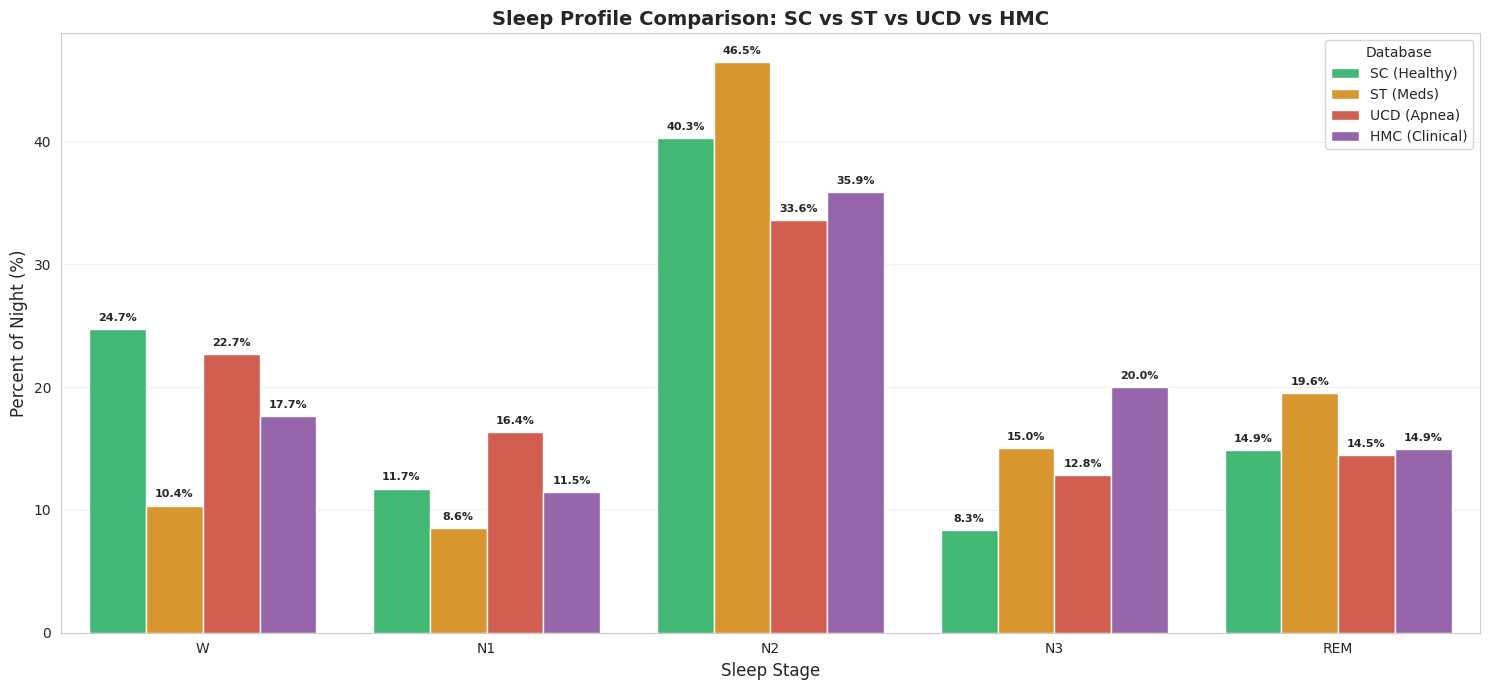

In [ ]:
all_files = glob.glob(os.path.join(base_dir, '**', '*.npz'), recursive=True)

sc_files = [f for f in all_files if "SC" in os.path.basename(f).upper()]
st_files = [f for f in all_files if "ST" in os.path.basename(f).upper()]
ucd_files = [f for f in all_files if "UCD" in os.path.basename(f).upper()]
hmc_files = [f for f in all_files if "HMC" in os.path.basename(f).upper()]

print(f"Total files found:")
print(f" - Sleep-EDF Healthy (SC): {len(sc_files)}")
print(f" - Sleep-EDF Mild/Meds (ST): {len(st_files)}")
print(f" - UCD Apnea (Severe): {len(ucd_files)}")
print(f" - HMC (Mixed/Clinical): {len(hmc_files)}")

datasets = [
    ('SC (Healthy)', sc_files),
    ('ST (Meds)', st_files),
    ('UCD (Apnea)', ucd_files),
    ('HMC (Clinical)', hmc_files)
]

plot_data = []
for label, files in datasets:
    if not files: continue
    counts, total = get_counts(files)
    if total == 0: continue

    for cls_idx in range(5):
        percentage = (counts[cls_idx] / total) * 100
        plot_data.append({
            'Dataset': label,
            'Stage': short_class_names[cls_idx],
            'Percent': percentage
        })

df_compare = pd.DataFrame(plot_data)

if not df_compare.empty:
    plt.figure(figsize=(15, 7))
    ax = sns.barplot(
        x='Stage', y='Percent', hue='Dataset', data=df_compare,
        palette=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
    )
    plt.title("Sleep Profile Comparison: SC vs ST vs UCD vs HMC", fontsize=14, fontweight='bold')
    plt.ylabel("Percent of Night (%)", fontsize=12)
    plt.xlabel("Sleep Stage", fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title='Database')

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.1f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8),
                        textcoords='offset points', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Class Distribution

,Class_ID,Class_Label,Count,Percentage (%),Weight
0,0,Wake (W),48348,21.19,0.9440
1,1,N1,25666,11.25,1.7783
2,2,N2,87244,38.23,0.5232
3,3,Deep (N3),31587,13.84,1.4450
4,4,REM,35368,15.50,1.2905


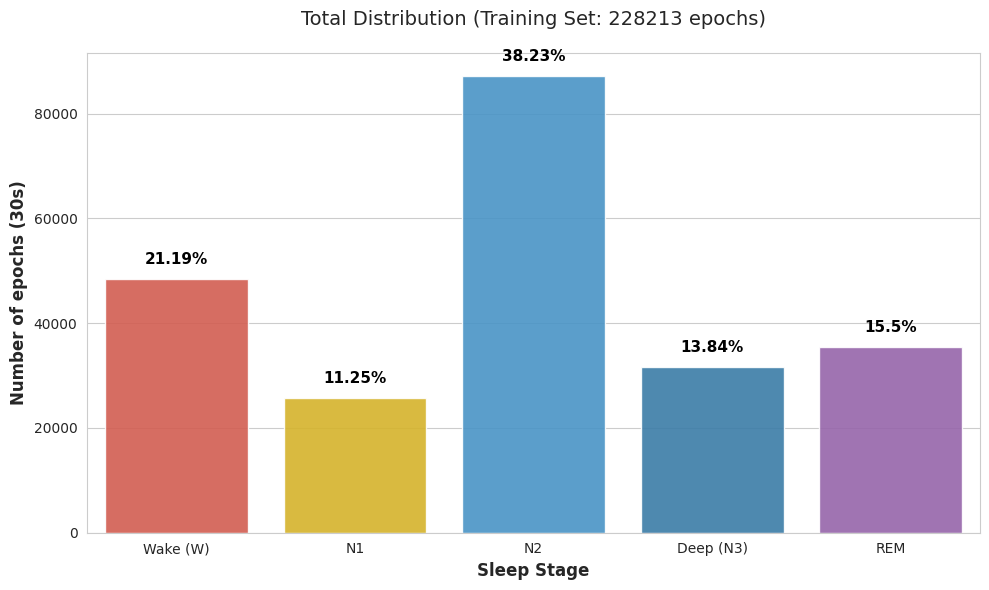

In [13]:
train_files = glob.glob(os.path.join(base_dir, 'train', '*.npz'))
train_counts, total_train = get_counts(train_files)

n_classes = 5
final_weights = {}
for cls_id in range(n_classes):
    count = train_counts.get(cls_id, 0)
    final_weights[cls_id] = total_train / (n_classes * count) if count > 0 else 0.0

def save_distribution_to_csv_and_plot_clean(counts, weights, output_filename, total_samples):
    data = []
    for cls_id in range(5):
        count = counts.get(cls_id, 0)
        weight = weights.get(cls_id, 1.0)
        label = class_names.get(cls_id, 'Unknown')
        percentage = (count / total_samples * 100) if total_samples > 0 else 0

        data.append({
            'Class_ID': cls_id,
            'Class_Label': label,
            'Count': count,
            'Percentage (%)': round(percentage, 2),
            'Weight': round(weight, 4)
        })

    df = pd.DataFrame(data)
    df.to_csv(output_filename, index=False)
    display(df)

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    palette = ['#e74c3c', '#f1c40f', '#3498db', '#2980b9', '#9b59b6']

    ax = sns.barplot(x='Class_Label', y='Count', data=df, hue='Class_Label', palette=palette, alpha=0.9, legend=False)

    plt.xlabel('Sleep Stage', fontsize=12, fontweight='bold')
    plt.ylabel('Number of epochs (30s)', fontsize=12, fontweight='bold')
    plt.title(f'Total Distribution (Training Set: {total_samples} epochs)', fontsize=14, pad=20)

    for p, percentage in zip(ax.patches, df['Percentage (%)']):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + (total_samples * 0.01),
                f'{percentage}%', ha="center", va="bottom",
                fontsize=11, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

if total_train > 0:
    save_distribution_to_csv_and_plot_clean(train_counts, final_weights, output_csv_name, total_train)
else:
    print("Error: train folder not found")

# Upload to Hugging Face

In [ ]:
# hf_token = SECRET
repo_id = "carmentheodora/Sleep_Quality_Dataset_Clean"

In [ ]:
disable_progress_bars()

hf_token = os.environ.get("HF_TOKEN", hf_token)

base_dir = '/content/drive/MyDrive/sleep_data/process_dataset'

api = HfApi()

print(f"Starting upload of folder '{base_dir}' to {repo_id}...")

try:
    api.upload_folder(
        folder_path=base_dir,
        repo_id=repo_id,
        repo_type="dataset",
        token=hf_token
    )
    print("Done upload in Hugging Face!")
except Exception as e:
    print(f"Error: {e}")

It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.


Starting upload of folder '/content/drive/MyDrive/sleep_data/process_dataset' to carmentheodora/Sleep_Quality_Dataset_Clean...
Done upload in Hugging Face!


---
# Conclusions and Next Step

In this notebook we have accomplished:
1. Download the HMC Dataset
2. Apply tranformation to look like the SC/ ST datasets.
3. Split between train, val and test.

The next step, AI/ML apply.